In [ ]:
!pip install roboflow

from roboflow import Roboflow
rf = Roboflow(api_key="yohvYOq709Ivpb0xby6I")
project = rf.workspace("omar-ibrahim-ju0qn").project("car-lisence-palate")
version = project.version(1)
dataset = version.download("yolov8")


loading Roboflow workspace...
loading Roboflow project...


In [ ]:
!pip install ultralytics roboflow

In [ ]:
from ultralytics import YOLO

model = YOLO('yolov8n.pt')


results = model.train(
    data=f"{dataset.location}/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    project="Egyptian_ALPR",
    name="plate_model",
    device=0              # لتأكيد استخدام كارت الشاشة (GPU)
)

Ultralytics 8.4.164 🚀 Python-3.13.15 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Car-lisence-palate-1/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=plate_model-2, nbs=64, nms=None, opset=None, opti

In [ ]:
from google.colab import files
# تنزيل ملف الموديل النهائي لجهازك
files.download('/content/runs/detect/Egyptian_ALPR/plate_model-2/weights/best.pt')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


image 1/203 /content/Car-lisence-palate-1/test/images/0003_jpg.rf.bb890faa0eb97f4912ae73aa9de2b7bd.jpg: 640x640 1 License Plate, 7.2ms
image 2/203 /content/Car-lisence-palate-1/test/images/0006_jpg.rf.f3b1e50f8cb03ab94d109116a264562b.jpg: 640x640 1 License Plate, 8.9ms
image 3/203 /content/Car-lisence-palate-1/test/images/0010_jpg.rf.5bdfb7fd2daed40264f0d814670692d8.jpg: 640x640 1 License Plate, 8.4ms
image 4/203 /content/Car-lisence-palate-1/test/images/0021_jpg.rf.3c29637de42c059f9c780aa84dc6b4b5.jpg: 640x640 1 License Plate, 8.2ms
image 5/203 /content/Car-lisence-palate-1/test/images/0032_jpg.rf.88cceb24c272eeb89b9db4eba1b90d21.jpg: 640x640 1 License Plate, 8.3ms
image 6/203 /content/Car-lisence-palate-1/test/images/0052_jpg.rf.8b21ef7a05bd4bf2a5341d9ac8f8bf47.jpg: 640x640 1 License Plate, 7.2ms
image 7/203 /content/Car-lisence-palate-1/test/images/0068_jpg.rf.d0edf3309e45c6d116c7cbf9f313b9c0.jpg: 640x640 2 License Plates, 11.5ms
image 8/203 /content/Car-lisence-palate-1/test/image

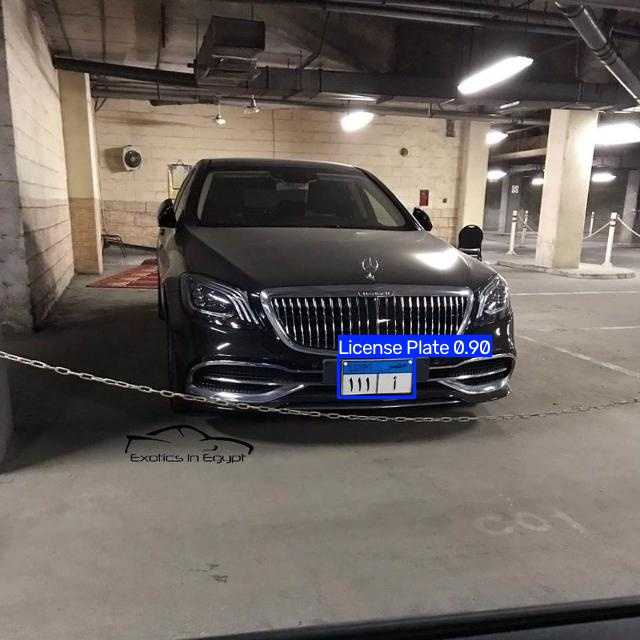

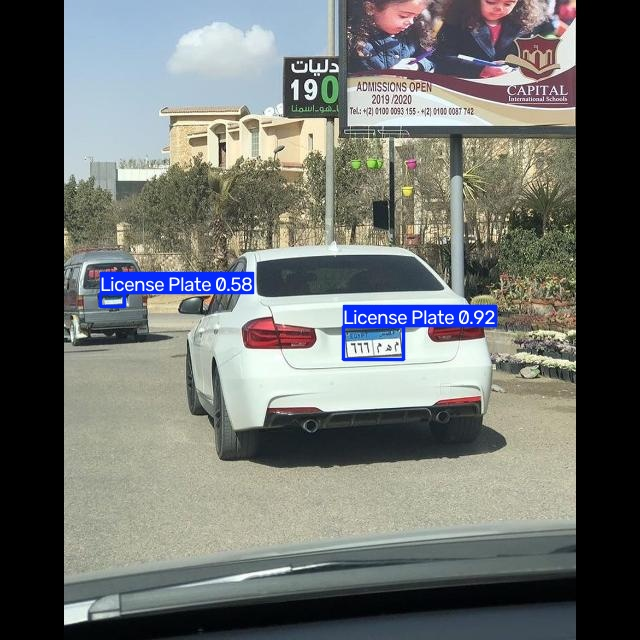

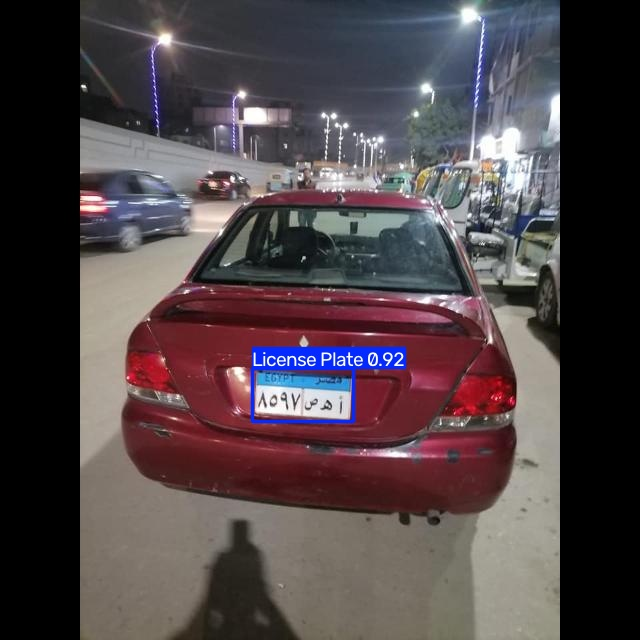

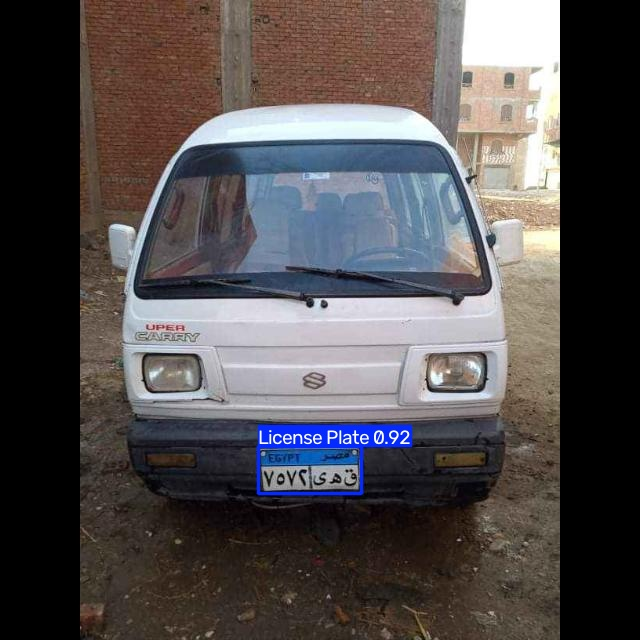

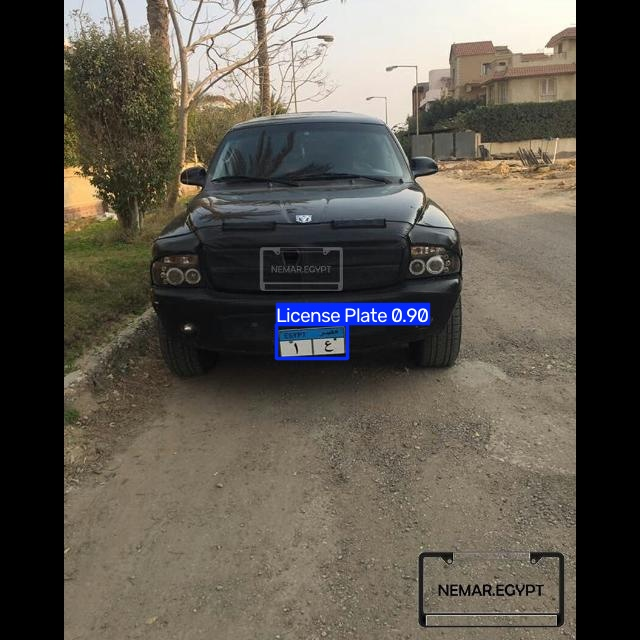

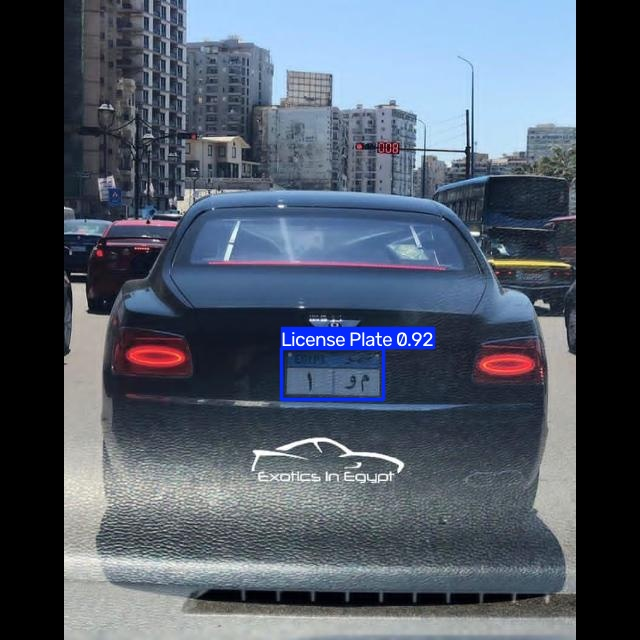

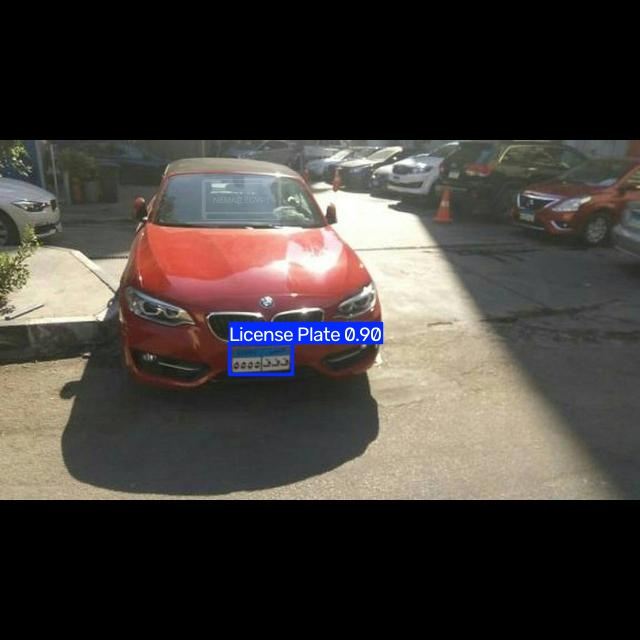

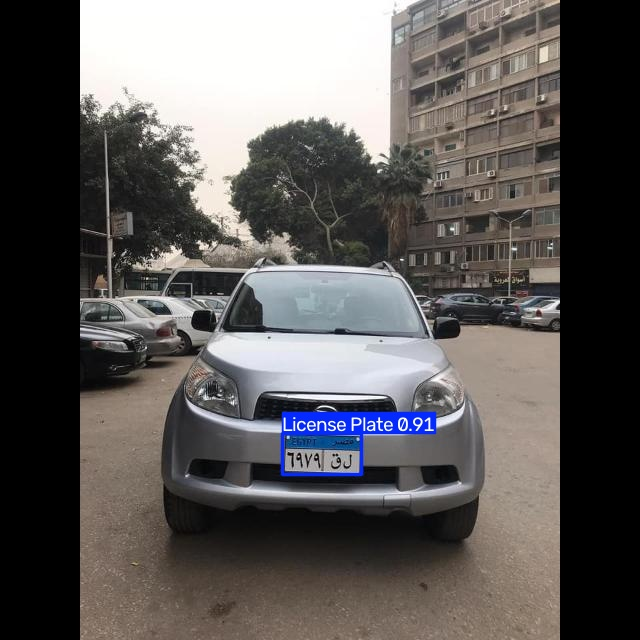

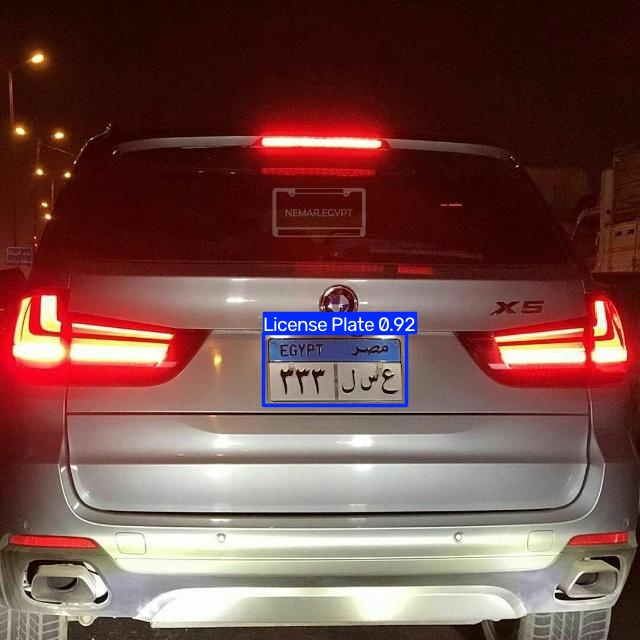

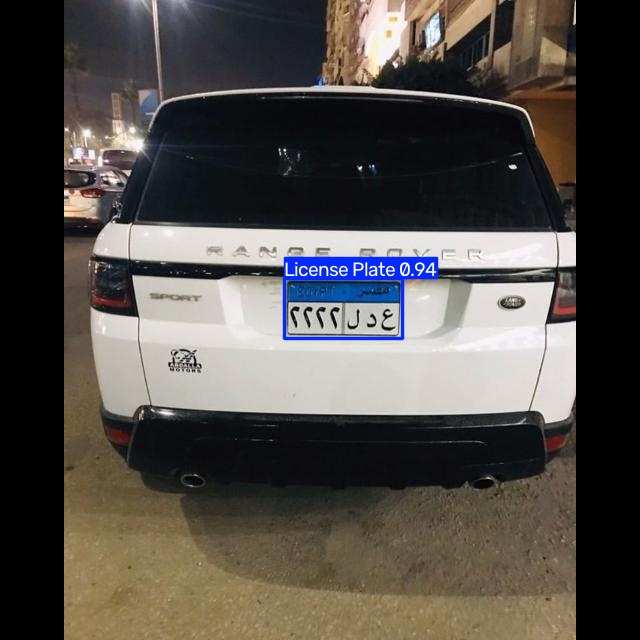

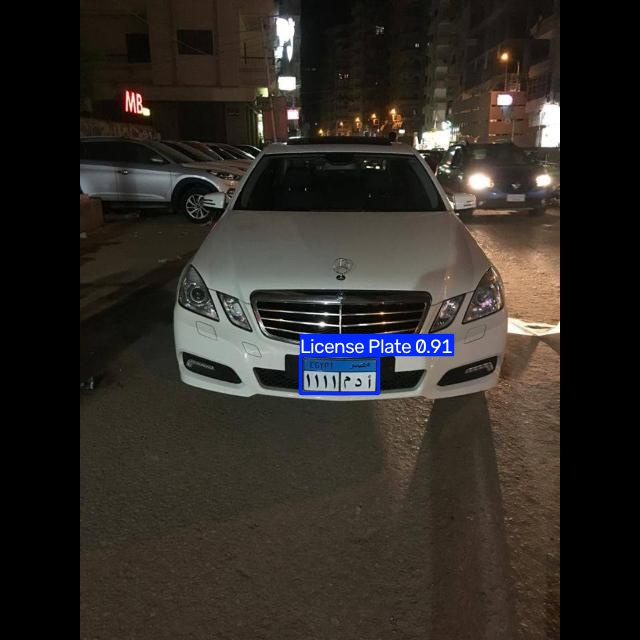

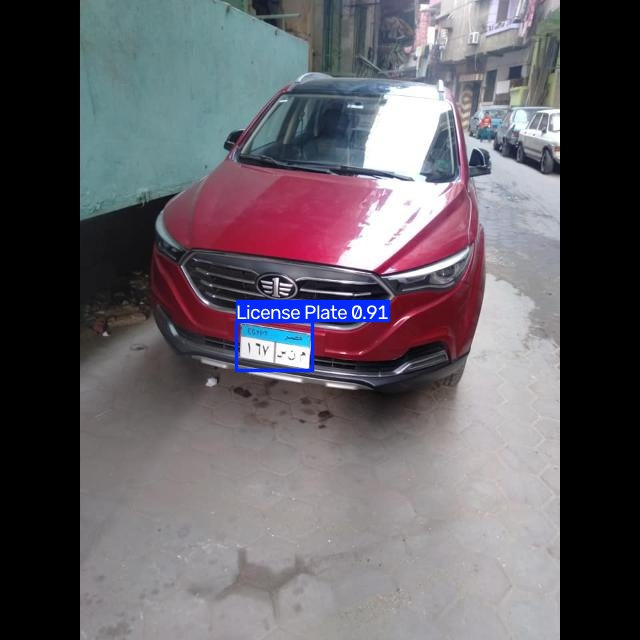

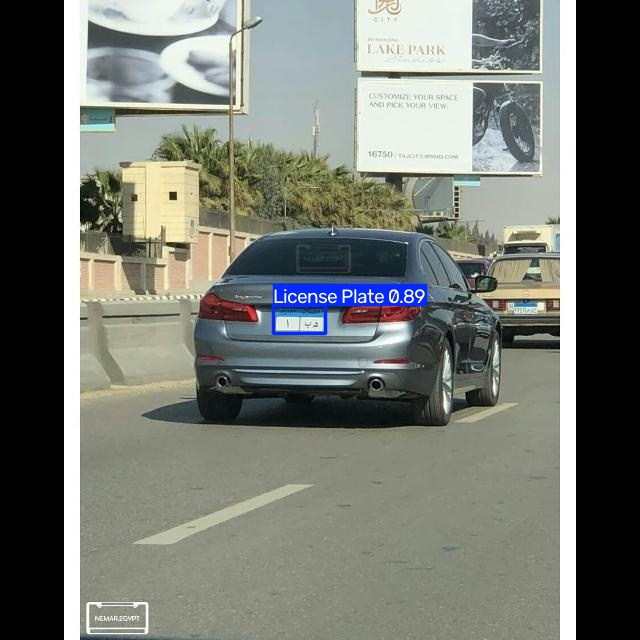

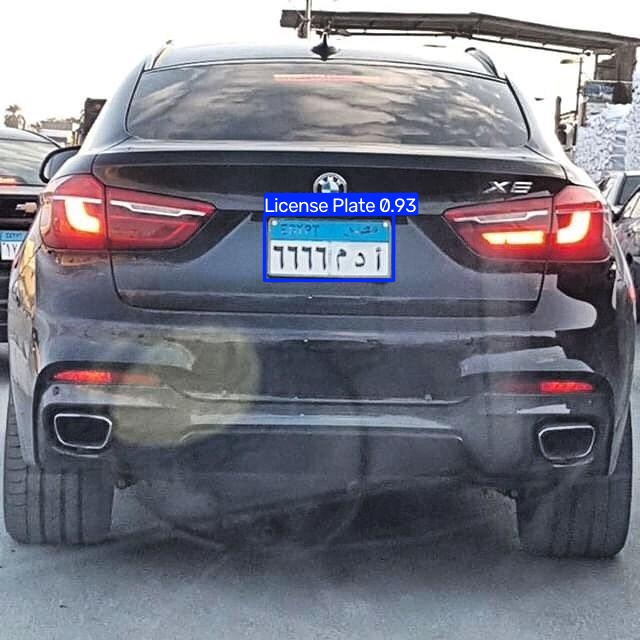

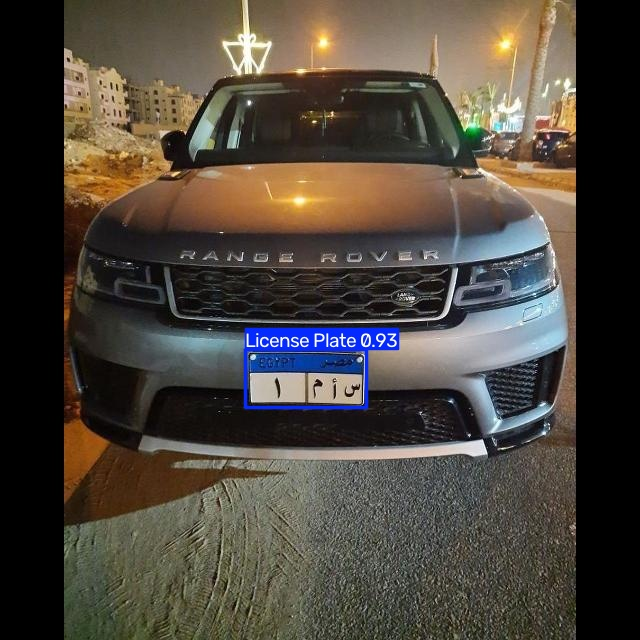

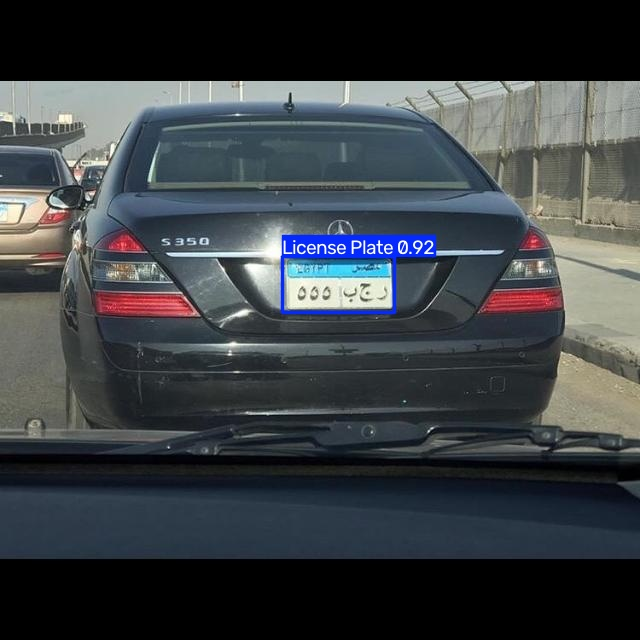

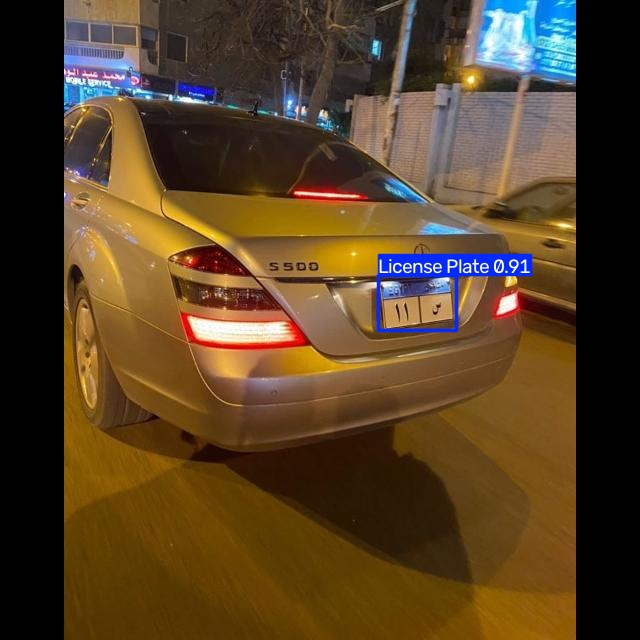

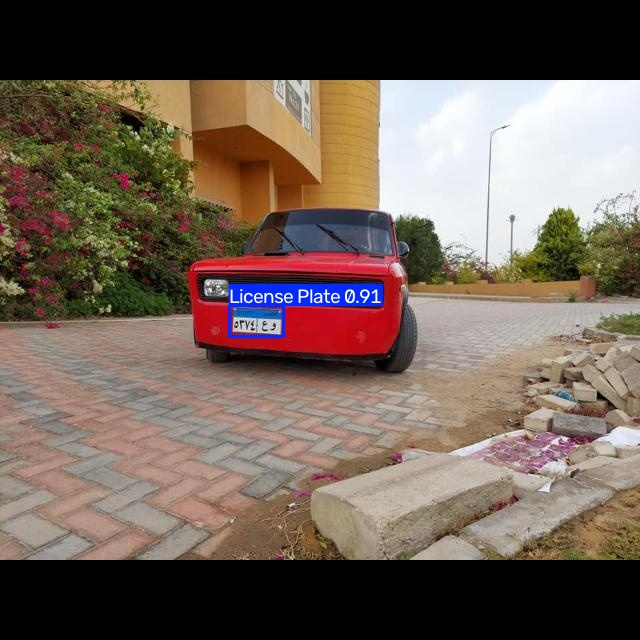

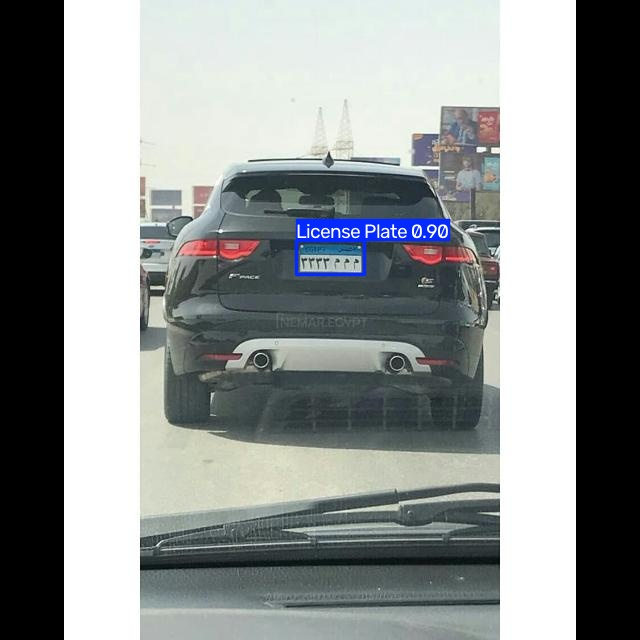

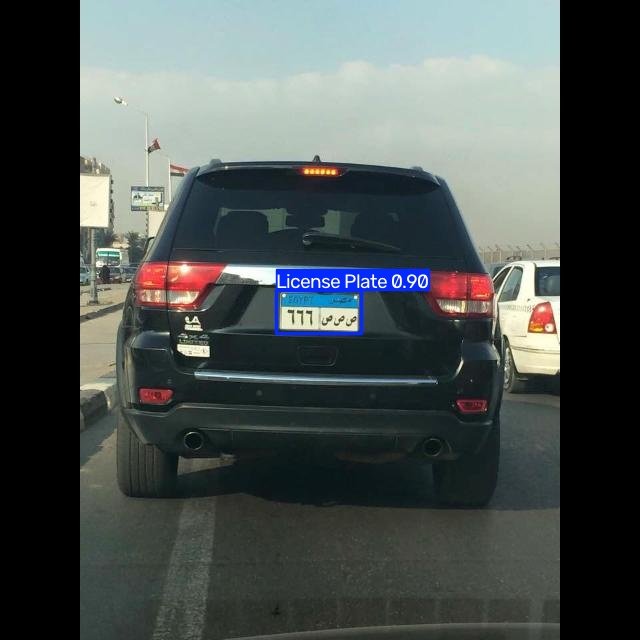

In [ ]:
from ultralytics import YOLO
import glob
from IPython.display import Image, display

# 1. تحميل الموديل الذي قمنا بتدريبه للتو
model = YOLO('/content/runs/detect/Egyptian_ALPR/plate_model-2/weights/best.pt')

# 2. تشغيل التوقع على فولدر الاختبار (Test) وحفظ النتائج
# تأكد من صحة مسار فولدر الـ test بناءً على ما ظهر في بياناتك
results = model.predict(source='/content/Car-lisence-palate-1/test/images', save=True, conf=0.5)

# 3. عرض أول 3 صور من النتائج المحفوظة
print("\nعرض عينة من النتائج:")
result_images = glob.glob('runs/detect/predict/*.jpg') # المسار الافتراضي لحفظ النتائج

for img_path in result_images[:20]:
    display(Image(filename=img_path, width=600))